<a href="https://colab.research.google.com/github/heoconngoc/Deep_Learning/blob/main/10_Modern_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================
# Setup
# =========================
import math, time, random, re, os, urllib.request
from collections import Counter
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device: cuda


In [3]:
# =========================
# Load & preprocess Time Machine (character-level)
# =========================
URL = "https://raw.githubusercontent.com/dsgiitr/d2l-pytorch/master/data/timemachine.txt"
path = "timemachine.txt"
if not os.path.exists(path):
    urllib.request.urlretrieve(URL, path)

with open(path, "r", encoding="utf-8") as f:
    lines = f.readlines()

def preprocess(lines):
    text = " ".join([re.sub("[^A-Za-z]+", " ", l).strip().lower() for l in lines])
    return re.sub(r"\s+", " ", text).strip()
    # Create a sequence of alphabet a->z, A->Z and single space

text = preprocess(lines)
vocab = sorted(list(set(text)))
stoi = {ch:i for i,ch in enumerate(vocab)} # String to index
itos = {i:ch for ch,i in stoi.items()} # Index to string
corpus = torch.tensor([stoi[ch] for ch in text], dtype=torch.long)

vocab_size = len(vocab)
print("text length:", len(text), "vocab_size:", vocab_size)
print("sample:", text[:120])

text length: 173427 vocab_size: 27
sample: the time machine by h g wells i the time traveller for so it will be convenient to speak of him was expounding a recondi


In [4]:
# =========================
# Sequence dataset (random sampling, truncated BPTT)
# =========================
class SeqDataset(Dataset):
    def __init__(self, corpus, num_steps):
        self.corpus = corpus
        self.num_steps = num_steps

    def __len__(self):
        return (len(self.corpus) - 1) // self.num_steps

    def __getitem__(self, idx):
        start = idx * self.num_steps
        x = self.corpus[start:start+self.num_steps]
        y = self.corpus[start+1:start+self.num_steps+1]
        return x, y

def get_dataloader(corpus, batch_size=32, num_steps=35):
    ds = SeqDataset(corpus, num_steps)
    return DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

def one_hot(x, vocab_size):
    # x: (B, T)
    return torch.nn.functional.one_hot(x, num_classes=vocab_size).float()

In [5]:
# =========================
# Models (RNN/GRU/LSTM) using nn.RNN/GRU/LSTM
# =========================
class CharRNNLM(nn.Module):
    def __init__(self, rnn_type, vocab_size, num_hiddens, num_layers=1, dropout=0.0):
        super().__init__()
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.rnn_type = rnn_type

        if rnn_type == "rnn":
            self.rnn = nn.RNN(vocab_size, num_hiddens, num_layers=num_layers,
                              dropout=dropout if num_layers > 1 else 0.0)
        elif rnn_type == "gru":
            self.rnn = nn.GRU(vocab_size, num_hiddens, num_layers=num_layers,
                              dropout=dropout if num_layers > 1 else 0.0)
        elif rnn_type == "lstm":
            self.rnn = nn.LSTM(vocab_size, num_hiddens, num_layers=num_layers,
                               dropout=dropout if num_layers > 1 else 0.0)
        else:
            raise ValueError("rnn_type must be one of: rnn, gru, lstm")

        self.fc = nn.Linear(num_hiddens, vocab_size)

    def forward(self, X, state=None):
        # X: (B, T) int
        X = one_hot(X, self.vocab_size).permute(1, 0, 2)  # -> (T, B, V)
        Y, state = self.rnn(X, state)                     # Y: (T, B, H)
        logits = self.fc(Y.reshape(-1, Y.shape[-1]))      # (T*B, V)
        return logits, state

    def begin_state(self, batch_size, device):
        num_directions = 1
        shape = (self.num_layers * num_directions, batch_size, self.num_hiddens)
        if self.rnn_type == "lstm":
            return (torch.zeros(shape, device=device), torch.zeros(shape, device=device))
        else:
            return torch.zeros(shape, device=device)

In [6]:
# =========================
# Training utils (perplexity, grad clipping, generate)
# =========================
def grad_clipping(net, theta):
    params = [p for p in net.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum(p.grad ** 2) for p in params if p.grad is not None))
    if norm > theta:
        for p in params:
            if p.grad is not None:
                p.grad[:] *= theta / (norm + 1e-6)

@torch.no_grad()
def predict(prefix, num_preds, net):
    net.eval()
    state = net.begin_state(batch_size=1, device=device)
    outputs = [stoi[prefix[0]]]
    # warm up
    for ch in prefix[1:]:
        X = torch.tensor([[outputs[-1]]], device=device)
        _, state = net(X, state)
        outputs.append(stoi[ch])
    # generate
    for _ in range(num_preds):
        X = torch.tensor([[outputs[-1]]], device=device)
        logits, state = net(X, state)
        p = torch.softmax(logits, dim=-1)
        next_id = int(torch.multinomial(p, num_samples=1))
        outputs.append(next_id)
    return "".join([itos[i] for i in outputs])

def train_lm(net, dataloader, lr=1.0, num_epochs=50, clip=1.0):
    net.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)

    history = {"ppl": [], "time": []}
    for epoch in range(num_epochs):
        net.train()
        total_loss, total_tokens = 0.0, 0
        start_t = time.time()

        for X, Y in dataloader:
            X, Y = X.to(device), Y.to(device)
            state = net.begin_state(X.shape[0], device=device)

            optimizer.zero_grad()
            logits, _ = net(X, state)
            y = Y.T.reshape(-1)  # (T*B,)
            loss = loss_fn(logits, y)
            loss.backward()
            grad_clipping(net, clip)
            optimizer.step()

            total_loss += float(loss) * y.numel()
            total_tokens += y.numel()

        ppl = math.exp(total_loss / total_tokens)
        history["ppl"].append(ppl)
        history["time"].append(time.time() - start_t)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            sample = predict("time traveller", 80, net)
            print(f"epoch {epoch+1:3d} | ppl {ppl:.2f} | {sample[:100]}")

    return history

In [7]:
# =========================
# Run comparison
# =========================
batch_size, num_steps = 32, 35
dl = get_dataloader(corpus, batch_size=batch_size, num_steps=num_steps)

configs = [
    ("rnn", 256, 1.0),
    ("gru", 256, 1.0),
    ("lstm", 256, 1.0),
]

results = {}
for rnn_type, H, lr in configs:
    print("\n====", rnn_type.upper(), "====")
    net = CharRNNLM(rnn_type, vocab_size, num_hiddens=H)
    hist = train_lm(net, dl, lr=lr, num_epochs=50, clip=1.0)
    results[rnn_type] = hist


==== RNN ====


/tmp/ipykernel_3127/1533543109.py:54: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total_loss += float(loss) * y.numel()


epoch   1 | ppl 11.87 | time traveller ritare wher pon d war no s manr shind fime tivf bt in tou gem in is bed on utun
epoch  10 | ppl 6.47 | time travellering of ti hell vinst of tresety for coust dof or helur hat hed the than that the
epoch  20 | ppl 5.23 | time traveller artiment keat of the rased weening to at soovide of the felices in the llokel a
epoch  30 | ppl 4.70 | time traveller spilbereding as cnoskeng save at the pusplent of the thirg i soulselust and wen
epoch  40 | ppl 4.41 | time traveller and metien plices and i was seethe oof in at was a dimered to the tere pabacese
epoch  50 | ppl 4.27 | time traveller apaided then some for or porking you i must hall in sout unlight they consuean 

==== GRU ====
epoch   1 | ppl 14.69 | time travelleroouss thren hate wohe illhe dm tiu vhe tee b ainunodeps hen tererer ath iaf fs s
epoch  10 | ppl 6.80 | time travellery gooskime hod were har i rectitelly of that sext in that hind to kan loft cevir
epoch  20 | ppl 5.22 | time traveller l

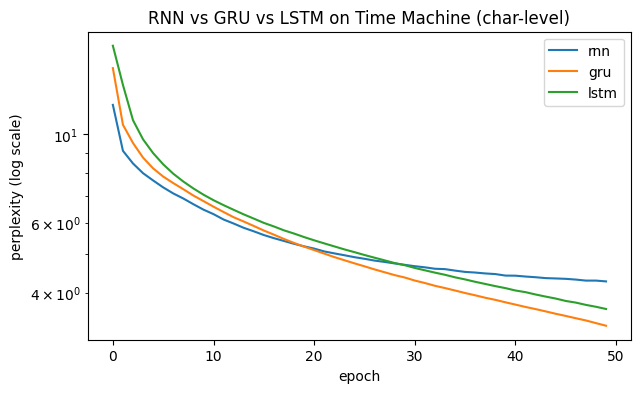

In [8]:
# =========================
# Plot perplexity curves
# =========================
plt.figure(figsize=(7,4))
for k, hist in results.items():
    plt.plot(hist["ppl"], label=k)
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("perplexity (log scale)")
plt.title("RNN vs GRU vs LSTM on Time Machine (char-level)")
plt.legend()
plt.show()

Natural Language Processing models based on LSTM often achieve lower perplexity than vanilla RNNs because they can capture long-term dependencies more effectively.

GRU models are usually more lightweight and computationally efficient than LSTMs, while still achieving comparable perplexity on many datasets.

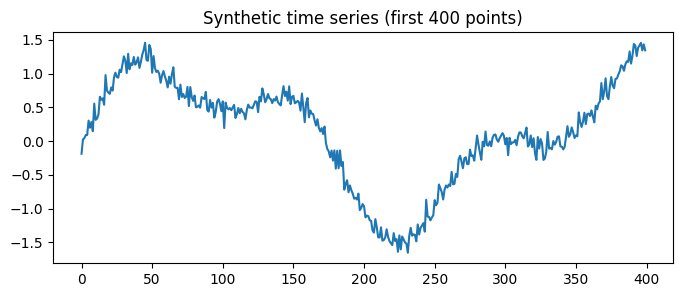

In [9]:
# =========================
# Create synthetic time series
# =========================
import numpy as np
set_seed(42)

T = 2000
t = np.arange(T)
series = np.sin(0.02*t) + 0.5*np.sin(0.05*t) + 0.1*np.random.randn(T)

plt.figure(figsize=(8,3))
plt.plot(series[:400])
plt.title("Synthetic time series (first 400 points)")
plt.show()

In [18]:
# =========================
# Build supervised dataset (window -> next value)
# =========================
class WindowDataset(Dataset):
    def __init__(self, series, window=50):
        self.x = []
        self.y = []
        for i in range(len(series) - window):
            self.x.append(series[i:i+window])
            self.y.append(series[i+window])
        self.x = torch.tensor(np.array(self.x), dtype=torch.float32).unsqueeze(-1)  # (N, W, 1)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32).unsqueeze(-1)  # (N, 1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

window = 50
ds = WindowDataset(series, window=window)
n_train = int(0.8 * len(ds))
train_ds, test_ds = torch.utils.data.random_split(ds, [n_train, len(ds)-n_train])
print("train_ds:", len(train_ds), "test_ds:", len(test_ds))

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
test_dl  = DataLoader(test_ds, batch_size=256, shuffle=False)

train_ds: 1560 test_ds: 390


In [11]:
# =========================
# LSTM forecaster
# =========================
class LSTMForecaster(nn.Module):
    def __init__(self, hidden=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        # x: (B, W, 1)
        out, _ = self.lstm(x)           # (B, W, H)
        last = out[:, -1, :]            # (B, H)
        return self.fc(last)            # (B, 1)

model = LSTMForecaster(hidden=64, num_layers=2, dropout=0.1).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epoch  5 | train_mse=0.01696 | test_mse=0.01676
epoch 10 | train_mse=0.01387 | test_mse=0.01369
epoch 15 | train_mse=0.01354 | test_mse=0.01346
epoch 20 | train_mse=0.01327 | test_mse=0.01326


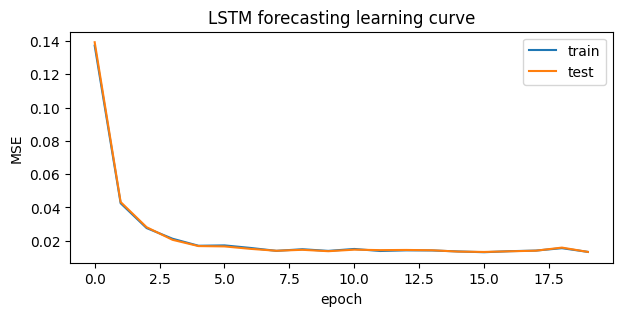

In [12]:
# =========================
# Train + evaluate + plot
# =========================
def eval_mse(model, dl):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            total += float(loss_fn(pred, y)) * x.size(0)
            n += x.size(0)
    return total / n

train_hist, test_hist = [], []
for epoch in range(20):
    model.train()
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
    train_mse = eval_mse(model, train_dl)
    test_mse  = eval_mse(model, test_dl)
    train_hist.append(train_mse)
    test_hist.append(test_mse)
    if (epoch+1) % 5 == 0:
        print(f"epoch {epoch+1:2d} | train_mse={train_mse:.5f} | test_mse={test_mse:.5f}")

plt.figure(figsize=(7,3))
plt.plot(train_hist, label="train")
plt.plot(test_hist, label="test")
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title("LSTM forecasting learning curve")
plt.legend(); plt.show()

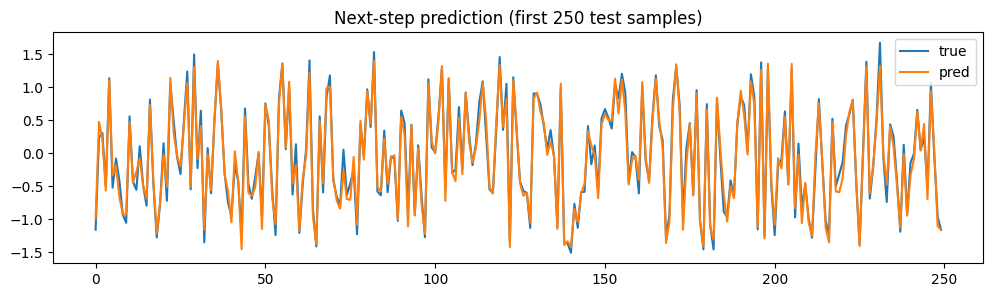

In [21]:
# =========================
# Visualize predictions on test segment
# =========================
model.eval()
x_batch, y_batch = next(iter(test_dl))
x_batch = x_batch.to(device)
with torch.no_grad():
    pred = model(x_batch).cpu().numpy().flatten()

true = y_batch.numpy().flatten()
plt.figure(figsize=(12,3))
plt.plot(true[:250], label="true")
plt.plot(pred[:250], label="pred")
plt.title("Next-step prediction (first 250 test samples)")
plt.legend()
plt.show()